In [1]:
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Charger le CSV
df = pd.read_csv("../data/dataset_selection.csv")

# Aperçu du dataset
print("Aperçu du dataset :")
print(df.head())

print(f"\nNombre total d'images : {len(df)}")

# Répartition des labels
class_counts = df['label'].value_counts()
print("\nRépartition des labels :")
print(class_counts)

Aperçu du dataset :
                                                path     label
0  /home/mathis/Memoire/data/glaucome/LAG/LAG/Tra...  glaucome
1  /home/mathis/Memoire/data/glaucome/LAG/LAG/Tra...  glaucome
2  /home/mathis/Memoire/data/glaucome/LAG/LAG/Tes...  glaucome
3  /home/mathis/Memoire/data/glaucome/LAG/LAG/Tra...  glaucome
4  /home/mathis/Memoire/data/glaucome/LAG/LAG/Tra...  glaucome

Nombre total d'images : 7796

Répartition des labels :
label
glaucome    1949
mda         1949
diabete     1949
normaux     1949
Name: count, dtype: int64


In [2]:
from sklearn.model_selection import train_test_split

df_train, df_test = train_test_split(
    df,
    test_size=0.1,
    stratify=df['label'],
    random_state=42
)

print("Tailles des splits :")
print(f"Train : {len(df_train)}")
print(f"Test : {len(df_test)}")

# Mapping label -> id
classes = sorted(df['label'].unique().tolist())
label_to_id = {c: i for i, c in enumerate(classes)}
print(f"\nClasses : {classes}")

Tailles des splits :
Train : 7016
Test : 780

Classes : ['diabete', 'glaucome', 'mda', 'normaux']


In [3]:
# Fonction pour enlever les bords noirs
def crop_black_border(img, thr=10, pad=10):
    if len(img.shape) == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        gray = img
    
    mask = gray > thr
    if not mask.any():
        return img
    
    ys, xs = np.where(mask)
    y0, y1 = ys.min(), ys.max()
    x0, x1 = xs.min(), xs.max()
    
    y0 = max(0, y0 - pad)
    x0 = max(0, x0 - pad)
    y1 = min(img.shape[0] - 1, y1 + pad)
    x1 = min(img.shape[1] - 1, x1 + pad)
    
    return img[y0:y1+1, x0:x1+1]

def load_image(path, size=(128, 128)):
    img = cv2.imread(path)
    if img is None:
        return None
    img = crop_black_border(img, thr=10, pad=10)
    img = cv2.resize(img, size)
    return img

def augment_image(img):
    aug = []
    h, w = img.shape[:2]
    for angle in [-15, 15]:
        M = cv2.getRotationMatrix2D((w//2, h//2), angle, 1)
        aug.append(cv2.warpAffine(img, M, (w, h)))
    aug.append(cv2.flip(img, 1))   # flip horizontal
    aug.append(cv2.flip(img, 0))   # flip vertical
    aug.append(np.clip(img.astype(np.float32) * 1.2 - 15, 0, 255).astype(np.uint8))
    return aug

print("Fonctions de prétraitement définies ✓")

Fonctions de prétraitement définies ✓


In [4]:
from skimage.feature import hog

def extract_hog_features(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    features = hog(
        gray,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm='L2-Hys',
        feature_vector=True
    )
    return features.astype(np.float32)

def extract_pixel_features(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return gray.flatten().astype(np.float32) / 255.0

print("Fonctions d'extraction de features définies ✓")
print(f"HOG sur image 128x128 donne {extract_hog_features(np.zeros((128, 128, 3), dtype=np.uint8)).shape[0]} features")
print(f"Pixels aplatis sur image 128x128 donne {128*128} features")

Fonctions d'extraction de features définies ✓
HOG sur image 128x128 donne 8100 features
Pixels aplatis sur image 128x128 donne 16384 features


In [5]:
def extract_all_features(df_subset, extract_func, augment=False):
    features = []
    labels = []
    valid_indices = []
    
    for idx, row in tqdm(df_subset.iterrows(), total=len(df_subset)):
        img = load_image(row['path'])
        if img is None:
            continue
        
        features.append(extract_func(img))
        labels.append(label_to_id[row['label']])
        valid_indices.append(idx)
        if augment:
            for aug_img in augment_image(img):
                features.append(extract_func(aug_img))
                labels.append(label_to_id[row['label']])
                valid_indices.append(idx)
    
    return np.array(features), np.array(labels), valid_indices

print("Extraction des features pixels (pour PCA)...")
X_train_pixels, y_train, _ = extract_all_features(df_train, extract_pixel_features, augment=True)
X_test_pixels, y_test, _ = extract_all_features(df_test, extract_pixel_features)

print(f"\nShape X_train_pixels: {X_train_pixels.shape}  (x6 avec augmentation)")
print(f"Shape X_test_pixels: {X_test_pixels.shape}")

Extraction des features pixels (pour PCA)...


  0%|          | 5/7016 [00:00<17:02,  6.86it/s][ WARN:0@6.280] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 11 (0xb) encountered
[ WARN:0@6.280] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 59932 (0xea1c) encountered
  2%|▏         | 158/7016 [00:10<08:02, 14.22it/s][ WARN:0@15.765] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 11 (0xb) encountered
[ WARN:0@15.765] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 59932 (0xea1c) encountered
  6%|▋         | 453/7016 [00:25<05:28, 19.95it/s][ WARN:0@31.321] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 11 (0xb) encountered
[ WARN:0@31.321] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 59932 (0xea1c) encountered
 11%|█▏        | 801/7016 [00:42<04:51, 21.32it/s][ WARN:0@48.159] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirector


Shape X_train_pixels: (42096, 16384)  (x6 avec augmentation)
Shape X_test_pixels: (780, 16384)


In [6]:
print("Extraction des features HOG...")
X_train_hog, _, _ = extract_all_features(df_train, extract_hog_features, augment=True)
X_test_hog, _, _ = extract_all_features(df_test, extract_hog_features)

print(f"\nShape X_train_hog: {X_train_hog.shape}  (x6 avec augmentation)")
print(f"Shape X_test_hog: {X_test_hog.shape}")

Extraction des features HOG...


  0%|          | 8/7016 [00:00<05:45, 20.26it/s][ WARN:0@381.275] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 11 (0xb) encountered
[ WARN:0@381.275] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 59932 (0xea1c) encountered
  2%|▏         | 160/7016 [00:11<07:45, 14.72it/s][ WARN:0@392.605] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 11 (0xb) encountered
[ WARN:0@392.605] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 59932 (0xea1c) encountered
  6%|▋         | 455/7016 [00:32<06:51, 15.93it/s][ WARN:0@412.913] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 11 (0xb) encountered
[ WARN:0@412.913] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 59932 (0xea1c) encountered
 11%|█▏        | 802/7016 [00:56<07:30, 13.79it/s][ WARN:0@437.082] global grfmt_tiff.cpp:122 TIFF_Warning TIFFRea


Shape X_train_hog: (42096, 8100)  (x6 avec augmentation)
Shape X_test_hog: (780, 8100)


In [7]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler_pixels = StandardScaler()
X_train_pixels_scaled = scaler_pixels.fit_transform(X_train_pixels).astype(np.float32)
X_test_pixels_scaled  = scaler_pixels.transform(X_test_pixels).astype(np.float32)
del X_train_pixels, X_test_pixels

print(f"Shape X_train_pixels_scaled: {X_train_pixels_scaled.shape}  float32")
print("PCA sera testée avec différents n_components dans le RandomizedSearchCV")

Shape X_train_pixels_scaled: (42096, 16384)  float32
PCA sera testée avec différents n_components dans le RandomizedSearchCV


In [8]:
scaler_hog = StandardScaler()
X_train_hog_scaled = scaler_hog.fit_transform(X_train_hog).astype(np.float32)
X_test_hog_scaled  = scaler_hog.transform(X_test_hog).astype(np.float32)
del X_train_hog, X_test_hog

n_pixel_features = X_train_pixels_scaled.shape[1]
n_hog_features   = X_train_hog_scaled.shape[1]

print(f"X_train_pixels_scaled : {X_train_pixels_scaled.shape}  float32")
print(f"X_train_hog_scaled    : {X_train_hog_scaled.shape}  float32")

X_train_pixels_scaled : (42096, 16384)  float32
X_train_hog_scaled    : (42096, 8100)  float32


In [9]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RandomizedSearchCV, ShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

knn_params = {
    'n_neighbors': [2,3, 5, 7, 9],
    'weights':     ['uniform', 'distance'],
    'metric':      ['euclidean', 'manhattan'],
}

pca_components = [30, 50, 75]

cv_split = ShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

results = {}

print("Paramètres KNN à tester:")
for key, values in knn_params.items():
    print(f"  {key}: {values}")
print(f"\nComposantes PCA à tester: {pca_components}")
print("\nNote: n_neighbors évite les multiples de 4 pour empêcher les égalités")
print(f"      (4 classes → vote à égalité si k est multiple de 4)")

Paramètres KNN à tester:
  n_neighbors: [2, 3, 5, 7, 9]
  weights: ['uniform', 'distance']
  metric: ['euclidean', 'manhattan']

Composantes PCA à tester: [30, 50, 75]

Note: n_neighbors évite les multiples de 4 pour empêcher les égalités
      (4 classes → vote à égalité si k est multiple de 4)


In [10]:
# 1. Pré-calcul PCA à la valeur max (1 seule fois)
print("Pré-calcul PCA...")
pca_full = PCA(n_components=max(pca_components), svd_solver='randomized', random_state=42)
X_pca_full = pca_full.fit_transform(X_train_pixels_scaled).astype(np.float32)
import gc
# Purge pixels
del X_train_pixels_scaled
gc.collect()

print(f"PCA max ({max(pca_components)}) calculé ✅")
# 2. Slice PCA + search pour chaque valeur
cv_split = ShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
best_score, best_params = 0, None

for k in pca_components:
    print(f"\n🔹 Test PCA({k})...", flush=True)

    # Slicing (pas de recalcul)
    X_k = X_pca_full[:, :k]

    grid = RandomizedSearchCV(
        KNeighborsClassifier(algorithm='ball_tree', n_jobs=-1),
        knn_params,
        n_iter=80,        cv=cv_split,
        scoring='accuracy',
        n_jobs=1,
        random_state=42,
        verbose=2
    )
    grid.fit(X_k, y_train)

    score = grid.best_score_
    print(f"   → {grid.best_params_} | accuracy: {score:.4f}", flush=True)

    if score > best_score:
        best_score = score
        best_params = {**grid.best_params_, 'pca_components': k}
print(f"\n{'='*60}")
print(f"GAGNANT: {best_params} → {best_score:.4f}")
print(f"{'='*60}")

Pré-calcul PCA...
PCA max (75) calculé ✅

🔹 Test PCA(30)...
Fitting 1 folds for each of 20 candidates, totalling 20 fits
[CV] END ...metric=euclidean, n_neighbors=2, weights=uniform; total time=   2.0s
[CV] END ..metric=euclidean, n_neighbors=2, weights=distance; total time=   1.9s
[CV] END ...metric=euclidean, n_neighbors=3, weights=uniform; total time=   2.3s
[CV] END ..metric=euclidean, n_neighbors=3, weights=distance; total time=   2.2s
[CV] END ...metric=euclidean, n_neighbors=5, weights=uniform; total time=   2.0s
[CV] END ..metric=euclidean, n_neighbors=5, weights=distance; total time=   2.0s
[CV] END ...metric=euclidean, n_neighbors=7, weights=uniform; total time=   1.2s
[CV] END ..metric=euclidean, n_neighbors=7, weights=distance; total time=   2.4s
[CV] END ...metric=euclidean, n_neighbors=9, weights=uniform; total time=   2.2s
[CV] END ..metric=euclidean, n_neighbors=9, weights=distance; total time=   2.1s
[CV] END ...metric=manhattan, n_neighbors=2, weights=uniform; total t


 Métrique                 Score
--------------------------------
 Test Accuracy           0.7423
 Balanced Acc            0.7423
 Precision               0.7416
 Recall                  0.7423
 F1 Score                0.7419


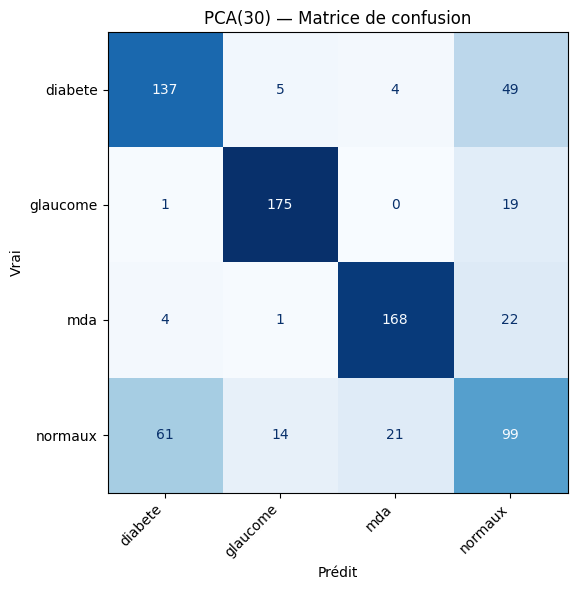

In [11]:
# Meilleur modèle ré-entraîné
best_k = best_params['pca_components']
X_test_best = X_test_pixels_scaled.astype(np.float32) @ pca_full.components_[:best_k].T

best_knn = KNeighborsClassifier(
    n_neighbors=best_params['n_neighbors'],
    weights=best_params['weights'],
    metric=best_params['metric'],    algorithm='ball_tree', n_jobs=-1
)
best_knn.fit(X_pca_full[:, :best_k], y_train)

y_pred = best_knn.predict(X_test_best)
acc = accuracy_score(y_test, y_pred)
bacc = balanced_accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
rec = recall_score(y_test, y_pred, average='macro', zero_division=0)
f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)

print(f"\n{'='*32}")
print(f"{' Métrique':<22} {'Score':>8}")
print(f"{'-'*32}")
print(f"{' Test Accuracy':<22} {acc:>8.4f}")
print(f"{' Balanced Acc':<22} {bacc:>8.4f}")
print(f"{' Precision':<22} {prec:>8.4f}")
print(f"{' Recall':<22} {rec:>8.4f}")
print(f"{' F1 Score':<22} {f1:>8.4f}")

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
                       display_labels=classes).plot(
    ax=ax, values_format='d', cmap='Blues', colorbar=False)
ax.set_title(f"PCA({best_k}) — Matrice de confusion")
ax.set_xlabel('Prédit'); ax.set_ylabel('Vrai')
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout(); plt.show()

RandomizedSearch pour: HOG (optimisé)
Features HOG: (42096, 8100)
Fitting 1 folds for each of 20 candidates, totalling 20 fits
[CV] END ...metric=euclidean, n_neighbors=2, weights=uniform; total time= 9.0min
[CV] END ..metric=euclidean, n_neighbors=2, weights=distance; total time= 8.8min
[CV] END ...metric=euclidean, n_neighbors=3, weights=uniform; total time= 9.0min
[CV] END ..metric=euclidean, n_neighbors=3, weights=distance; total time= 8.5min
[CV] END ...metric=euclidean, n_neighbors=5, weights=uniform; total time= 8.4min
[CV] END ..metric=euclidean, n_neighbors=5, weights=distance; total time= 8.5min
[CV] END ...metric=euclidean, n_neighbors=7, weights=uniform; total time= 8.5min
[CV] END ..metric=euclidean, n_neighbors=7, weights=distance; total time= 8.4min
[CV] END ...metric=euclidean, n_neighbors=9, weights=uniform; total time= 8.4min
[CV] END ..metric=euclidean, n_neighbors=9, weights=distance; total time= 8.4min
[CV] END ...metric=manhattan, n_neighbors=2, weights=uniform; t

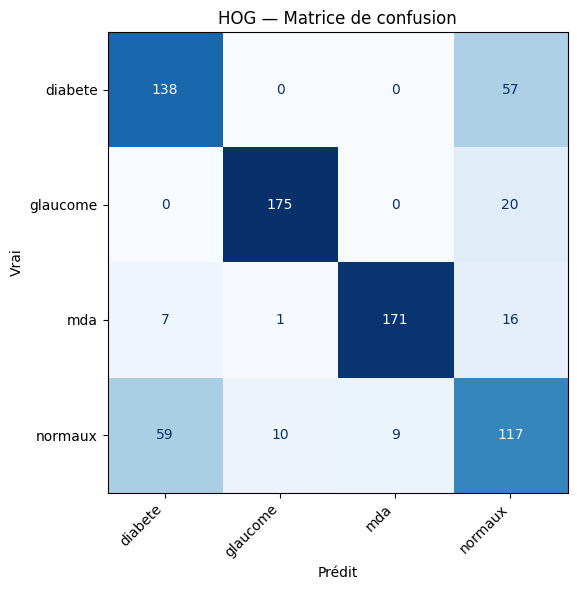

In [12]:
print("="*60)
print("RandomizedSearch pour: HOG (optimisé)")
print("="*60)

# Conversion float32 + normalisation déjà faite
print(f"Features HOG: {X_train_hog_scaled.shape}")

grid_hog = RandomizedSearchCV(
    KNeighborsClassifier(algorithm='ball_tree', n_jobs=-1),  # threads
    knn_params,
    n_iter=80,
    cv=ShuffleSplit(n_splits=1, test_size=0.2, random_state=42),
    scoring='accuracy',
    n_jobs=1,
    random_state=42,    verbose=2
)
grid_hog.fit(X_train_hog_scaled.astype(np.float32), y_train)

best_hog = grid_hog.best_estimator_
print(f'\n🏆 {grid_hog.best_params_} → val: {grid_hog.best_score_:.4f}')

# --- Résultats test ---
y_pred = best_hog.predict(X_test_hog_scaled.astype(np.float32))
acc = accuracy_score(y_test, y_pred)
bacc = balanced_accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
rec = recall_score(y_test, y_pred, average='macro', zero_division=0)
f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
print(f"\n{' Métrique':<22} {'Score':>8}")
print(f"{'-'*32}")
print(f"{' Test Accuracy':<22} {acc:>8.4f}")
print(f"{' Balanced Acc':<22} {bacc:>8.4f}")
print(f"{' Precision':<22} {prec:>8.4f}")
print(f"{' Recall':<22} {rec:>8.4f}")
print(f"{' F1 Score':<22} {f1:>8.4f}")

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
                       display_labels=classes).plot(
    ax=ax, values_format='d', cmap='Blues', colorbar=False)
ax.set_title("HOG — Matrice de confusion")
ax.set_xlabel('Prédit'); ax.set_ylabel('Vrai')
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()


PCA 30 + HOG


PCA=30 | CV=0.8643 | Test=0.7795

PCA 50 + HOG
PCA=50 | CV=0.8638 | Test=0.7692

Classement des PCA :
   PCA  CV Accuracy  Test Accuracy  \
0   30     0.864252       0.779487   
1   50     0.863777       0.769231   

                                         Best Params  
0  {'weights': 'distance', 'n_neighbors': 3, 'met...  
1  {'weights': 'distance', 'n_neighbors': 3, 'met...  

Meilleur PCA : 30
Meilleure Accuracy : 0.7795

===== METRIQUES =====
Accuracy  : 0.7795
Precision : 0.7746
Recall    : 0.7795
F1-score  : 0.7761

===== RAPPORT COMPLET =====
              precision    recall  f1-score   support

     diabete       0.68      0.74      0.71       195
    glaucome       0.90      0.93      0.92       195
         mda       0.92      0.92      0.92       195
     normaux       0.60      0.52      0.56       195

    accuracy                           0.78       780
   macro avg       0.77      0.78      0.78       780
weighted avg       0.77      0.78      0.78       780



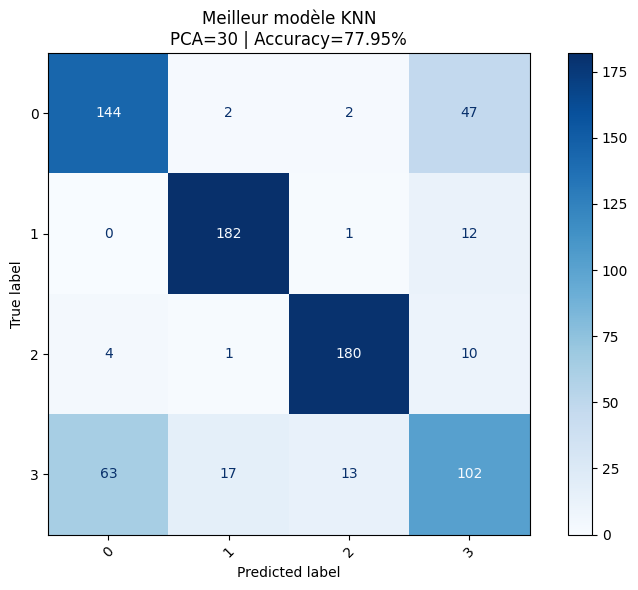

In [10]:
import gc
results = []
pca_components = [30, 50]

best_test_acc = -1
best_model = None
best_pca = None
best_X_test = None

for n_comp in pca_components:

    print(f"\nPCA {n_comp} + HOG")

    pca = PCA(
        n_components=n_comp,
        svd_solver='randomized',
        random_state=42
    )

    X_train_pca = pca.fit_transform(X_train_pixels_scaled).astype(np.float32)
    X_test_pca = pca.transform(X_test_pixels_scaled).astype(np.float32)

    X_train_combined = np.hstack([X_train_pca, X_train_hog_scaled])
    X_test_combined = np.hstack([X_test_pca, X_test_hog_scaled])

    knn = KNeighborsClassifier(
        algorithm='ball_tree',
        n_jobs=-1
    )

    grid = RandomizedSearchCV(
        knn,
        knn_params,
        n_iter=60,
        cv=ShuffleSplit(
            n_splits=1,
            test_size=0.2,
            random_state=42
        ),
        scoring='accuracy',
        n_jobs=1,
        verbose=0,
        random_state=42
    )

    grid.fit(X_train_combined, y_train)

    best_knn = grid.best_estimator_

    y_pred = best_knn.predict(X_test_combined)
    test_acc = accuracy_score(y_test, y_pred)

    results.append({
        "PCA": n_comp,
        "CV Accuracy": grid.best_score_,
        "Test Accuracy": test_acc,
        "Best Params": grid.best_params_
    })

    print(
        f"PCA={n_comp} | "
        f"CV={grid.best_score_:.4f} | "
        f"Test={test_acc:.4f}"
    )

    # Sauvegarde du meilleur modèle
    if test_acc > best_test_acc:

        best_test_acc = test_acc
        best_model = best_knn
        best_pca = n_comp

        # garder uniquement les features du meilleur modèle
        best_X_test = X_test_combined.copy()

    del pca, X_train_pca, X_test_pca
    del X_train_combined, y_pred, grid
    gc.collect()


# ===============================
# Résultats finaux
# ===============================

results_df = pd.DataFrame(results)

print("\nClassement des PCA :")
print(results_df.sort_values("Test Accuracy", ascending=False))

print(f"\nMeilleur PCA : {best_pca}")
print(f"Meilleure Accuracy : {best_test_acc:.4f}")

# ===============================
# Métriques du meilleur modèle
# ===============================

y_pred_best = best_model.predict(best_X_test)

acc = accuracy_score(y_test, y_pred_best)
prec = precision_score(y_test, y_pred_best, average='weighted')
rec = recall_score(y_test, y_pred_best, average='weighted')
f1 = f1_score(y_test, y_pred_best, average='weighted')

print("\n===== METRIQUES =====")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1-score  : {f1:.4f}")

print("\n===== RAPPORT COMPLET =====")
print(classification_report(
    y_test,
    y_pred_best,
    target_names=classes
))

# ===============================
# Matrice de confusion
# ===============================

fig, ax = plt.subplots(figsize=(8, 6))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_best,
    cmap="Blues",
    xticks_rotation=45,
    ax=ax
)

ax.set_title(
    f"Meilleur modèle KNN\n"
    f"PCA={best_pca} | Accuracy={acc:.2%}"
)

plt.tight_layout()
plt.show()


PCA 75 + HOG
PCA=75 | CV=0.8647 | Test=0.7782

Classement des PCA :
   PCA  CV Accuracy  Test Accuracy  \
0   75     0.864727       0.778205   

                                         Best Params  
0  {'weights': 'distance', 'n_neighbors': 3, 'met...  

Meilleur PCA : 75
Meilleure Accuracy : 0.7782

===== METRIQUES =====
Accuracy  : 0.7782
Precision : 0.7738
Recall    : 0.7782
F1-score  : 0.7754

===== RAPPORT COMPLET =====
              precision    recall  f1-score   support

     diabete       0.67      0.71      0.69       195
    glaucome       0.90      0.93      0.92       195
         mda       0.93      0.93      0.93       195
     normaux       0.59      0.53      0.56       195

    accuracy                           0.78       780
   macro avg       0.77      0.78      0.78       780
weighted avg       0.77      0.78      0.78       780



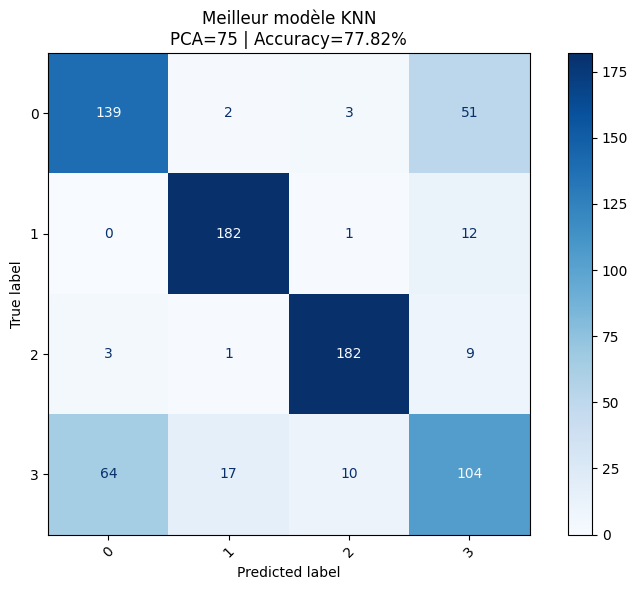

In [10]:
import gc
results = []
pca_components = [75]

best_test_acc = -1
best_model = None
best_pca = None
best_X_test = None

for n_comp in pca_components:

    print(f"\nPCA {n_comp} + HOG")

    pca = PCA(
        n_components=n_comp,
        svd_solver='randomized',
        random_state=42
    )

    X_train_pca = pca.fit_transform(X_train_pixels_scaled).astype(np.float32)
    X_test_pca = pca.transform(X_test_pixels_scaled).astype(np.float32)

    X_train_combined = np.hstack([X_train_pca, X_train_hog_scaled])
    X_test_combined = np.hstack([X_test_pca, X_test_hog_scaled])

    knn = KNeighborsClassifier(
        algorithm='ball_tree',
        n_jobs=-1
    )

    grid = RandomizedSearchCV(
        knn,
        knn_params,
        n_iter=60,
        cv=ShuffleSplit(
            n_splits=1,
            test_size=0.2,
            random_state=42
        ),
        scoring='accuracy',
        n_jobs=1,
        verbose=0,
        random_state=42
    )

    grid.fit(X_train_combined, y_train)

    best_knn = grid.best_estimator_

    y_pred = best_knn.predict(X_test_combined)
    test_acc = accuracy_score(y_test, y_pred)

    results.append({
        "PCA": n_comp,
        "CV Accuracy": grid.best_score_,
        "Test Accuracy": test_acc,
        "Best Params": grid.best_params_
    })

    print(
        f"PCA={n_comp} | "
        f"CV={grid.best_score_:.4f} | "
        f"Test={test_acc:.4f}"
    )

    # Sauvegarde du meilleur modèle
    if test_acc > best_test_acc:

        best_test_acc = test_acc
        best_model = best_knn
        best_pca = n_comp

        # garder uniquement les features du meilleur modèle
        best_X_test = X_test_combined.copy()

    del pca, X_train_pca, X_test_pca
    del X_train_combined, y_pred, grid
    gc.collect()


# ===============================
# Résultats finaux
# ===============================

results_df = pd.DataFrame(results)

print("\nClassement des PCA :")
print(results_df.sort_values("Test Accuracy", ascending=False))

print(f"\nMeilleur PCA : {best_pca}")
print(f"Meilleure Accuracy : {best_test_acc:.4f}")

# ===============================
# Métriques du meilleur modèle
# ===============================

y_pred_best = best_model.predict(best_X_test)

acc = accuracy_score(y_test, y_pred_best)
prec = precision_score(y_test, y_pred_best, average='weighted')
rec = recall_score(y_test, y_pred_best, average='weighted')
f1 = f1_score(y_test, y_pred_best, average='weighted')

print("\n===== METRIQUES =====")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1-score  : {f1:.4f}")

print("\n===== RAPPORT COMPLET =====")
print(classification_report(
    y_test,
    y_pred_best,
    target_names=classes
))

# ===============================
# Matrice de confusion
# ===============================

fig, ax = plt.subplots(figsize=(8, 6))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_best,
    cmap="Blues",
    xticks_rotation=45,
    ax=ax
)

ax.set_title(
    f"Meilleur modèle KNN\n"
    f"PCA={best_pca} | Accuracy={acc:.2%}"
)

plt.tight_layout()
plt.show()

PCA 30 sur pixels...
Projection 2D...
KNN 2D...


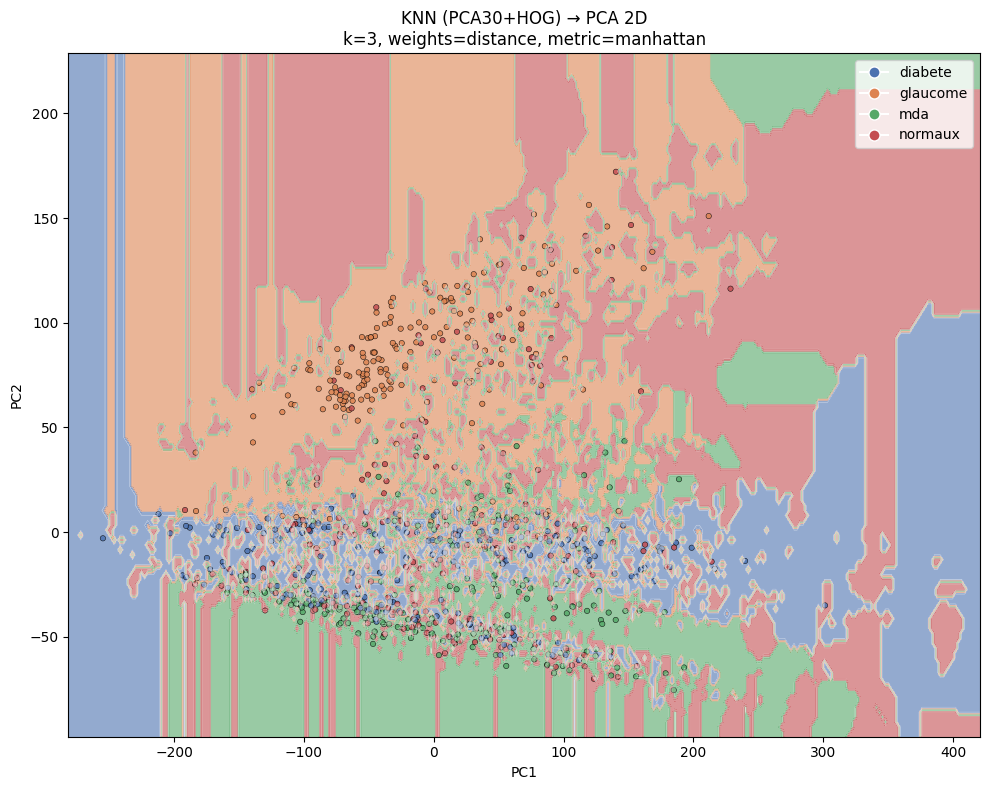

In [12]:
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D

best_pca = 30
best_k = 3
best_weights = 'distance'
best_metric = 'manhattan'

print("PCA 30 sur pixels...")
pca = PCA(n_components=best_pca, svd_solver='randomized', random_state=42)
X_train_pca = pca.fit_transform(X_train_pixels_scaled).astype(np.float32)
X_test_pca = pca.transform(X_test_pixels_scaled).astype(np.float32)
X_train_comb = np.hstack([X_train_pca, X_train_hog_scaled])
X_test_comb = np.hstack([X_test_pca, X_test_hog_scaled])

print("Projection 2D...")
pca_vis = PCA(n_components=2, random_state=42)
X_train_2d = pca_vis.fit_transform(X_train_comb)
X_test_2d = pca_vis.transform(X_test_comb)

print("KNN 2D...")
knn_2d = KNeighborsClassifier(
    n_neighbors=best_k, weights=best_weights,
    metric=best_metric, algorithm='ball_tree', n_jobs=-1
)
knn_2d.fit(X_train_2d, y_train)
# Grille
x_min, x_max = X_train_2d[:,0].min()-1, X_train_2d[:,0].max()+1
y_min, y_max = X_train_2d[:,1].min()-1, X_train_2d[:,1].max()+1
h = (x_max - x_min) / 300
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
Z = knn_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

# Plot
classes_labels = ['diabete', 'glaucome', 'mda', 'normaux']
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
cmap_bg = ListedColormap([c + '55' for c in colors])
cmap_pts = ListedColormap(colors)

fig, ax = plt.subplots(figsize=(10, 8))
ax.contourf(xx, yy, Z, cmap=cmap_bg, alpha=0.6)
ax.contour(xx, yy, Z, colors='white', linewidths=0.4, alpha=0.5)
ax.scatter(X_test_2d[:,0], X_test_2d[:,1], c=y_test, cmap=cmap_pts,
           edgecolors='k', linewidths=0.4, s=15, alpha=0.85)
legend_elements = [Line2D([0],[0], marker='o', color='w',
           markerfacecolor=colors[i], markersize=8, label=classes_labels[i])
           for i in range(len(classes_labels))]
ax.legend(handles=legend_elements, loc='best')
ax.set_title(f'KNN (PCA{best_pca}+HOG) → PCA 2D\n'
             f'k={best_k}, weights={best_weights}, metric={best_metric}')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
plt.tight_layout()
plt.show()